# 1. Elección de modelo ML

## 1.1 Dependencia de la cantidad de data

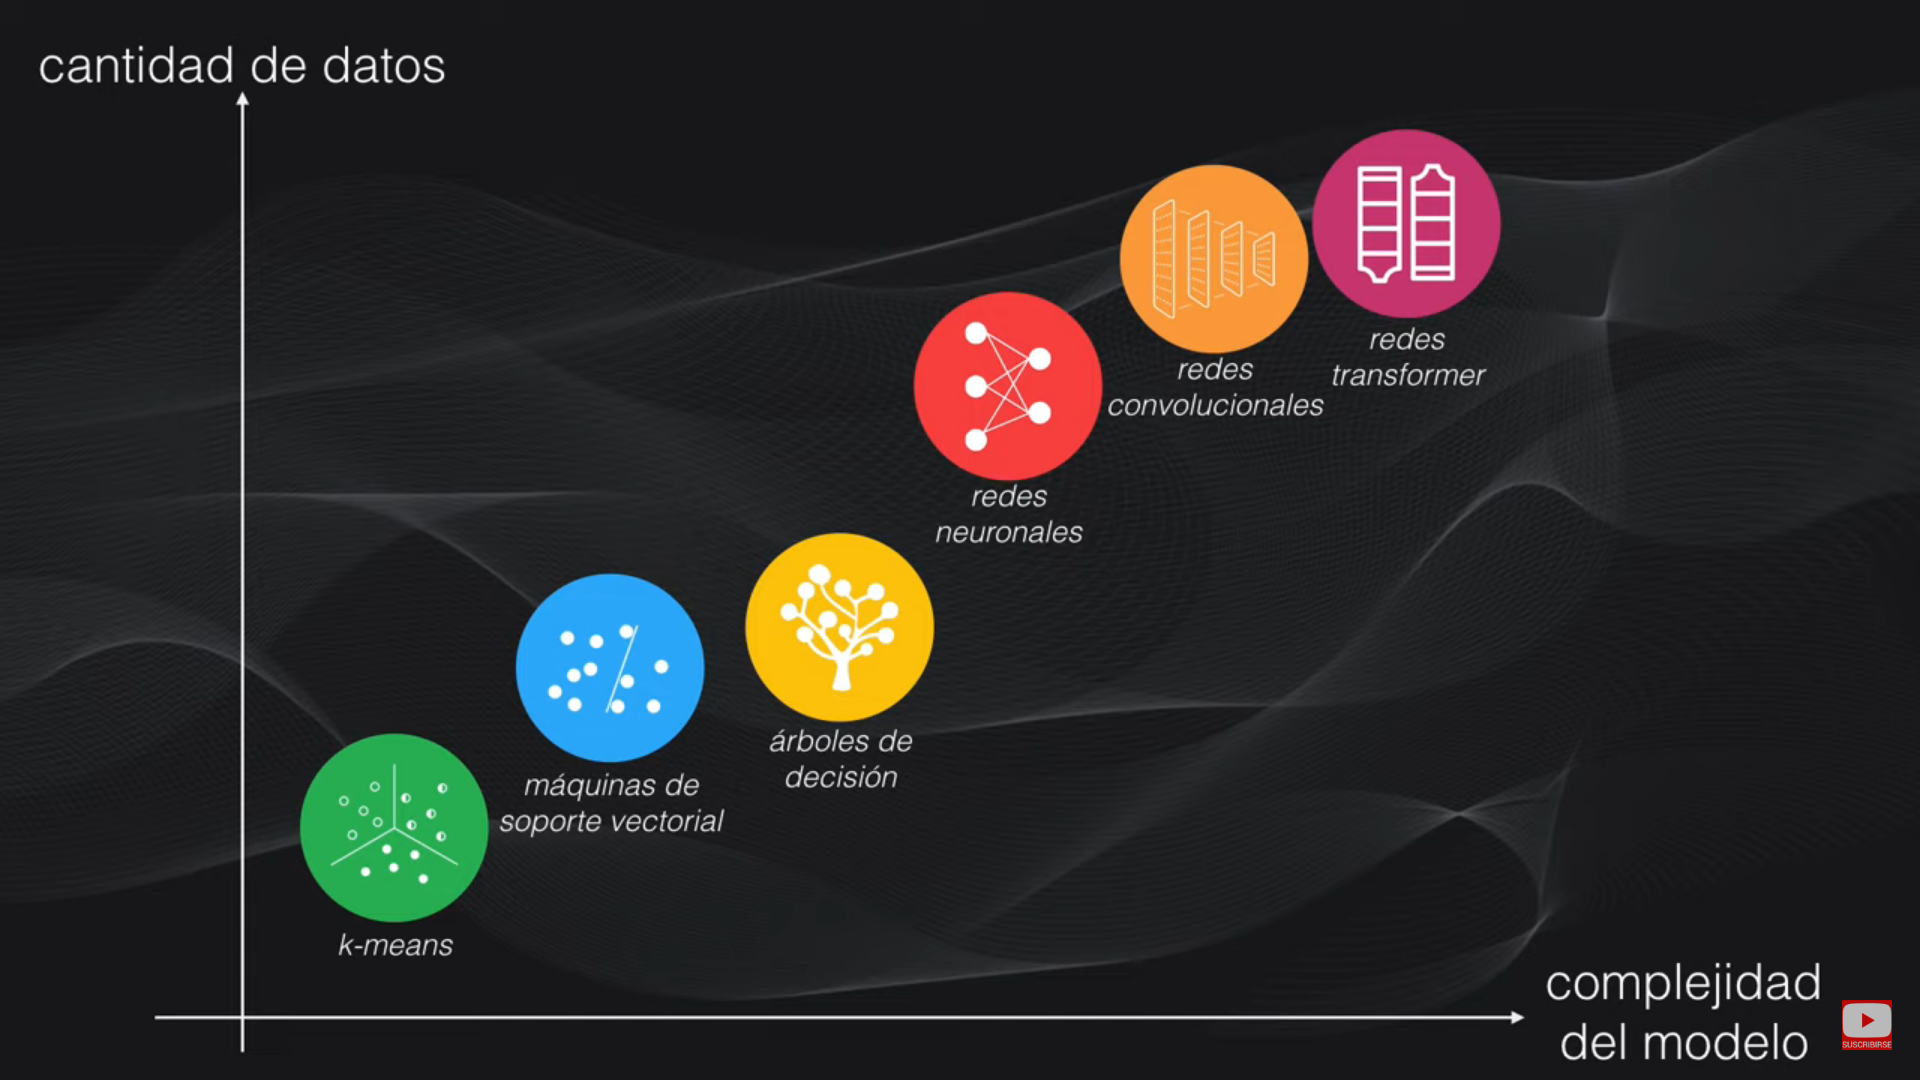

# 2. Modelo de calculo de radiación

## 2.1 Modelo Bristow-Campbell

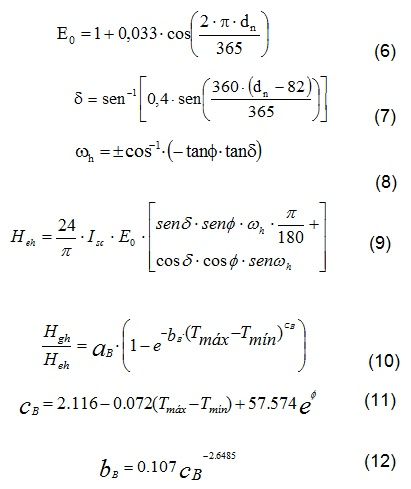

d_n: Día Juliano

pi : 3.14159265

\Delta : declinación solar

\Phi : latitud

\Theta_h : angulo horario

E_0 : factor de corrección de excentricidad de la órbita terrestre

I_sc : constante solar

H_eh : radiación solar incidente extraterrestre en un plano horizontal

c_B : 

T_min : temperatura mínima

T_max: temperatura máxima

b_B : 

a_B : 

H_gh : radiación solar global en un plano horizontal

## 2.2 Modelo de Bird y Hulstrom

(Sacado del iqbal)
Este modelo se basa en dos estudios de Bird y Hulstrom [15, 16].

En el primer estudio [15] Bird y Hulstrom llevaron a cabo una comparación detallada de un gran número de modelos de insolación directa.

Compararon elementos individuales de varios modelos con el modelo riguroso, llamado SOLTRAN, que se construyó a partir de LOWTRAN [17, 18]

NTP - Normal Temperature and Pressure
NTP is commonly used  as a standard condition  for testing and documentation of fan capacities:

NTP - Normal Temperature and Pressure - is defined as air at 20oC (293.15 K, 68oF) and 1 atm (101.325 kN/m2, 101.325 kPa, 14.7 psia, 0 psig, 29.92 in Hg, 407 in H2O, 760 torr). Density 1.204 kg/m3 (0.075 pounds per cubic foot)
At these conditions, the volume of 1 mol of a gas is 24.0548 liters.

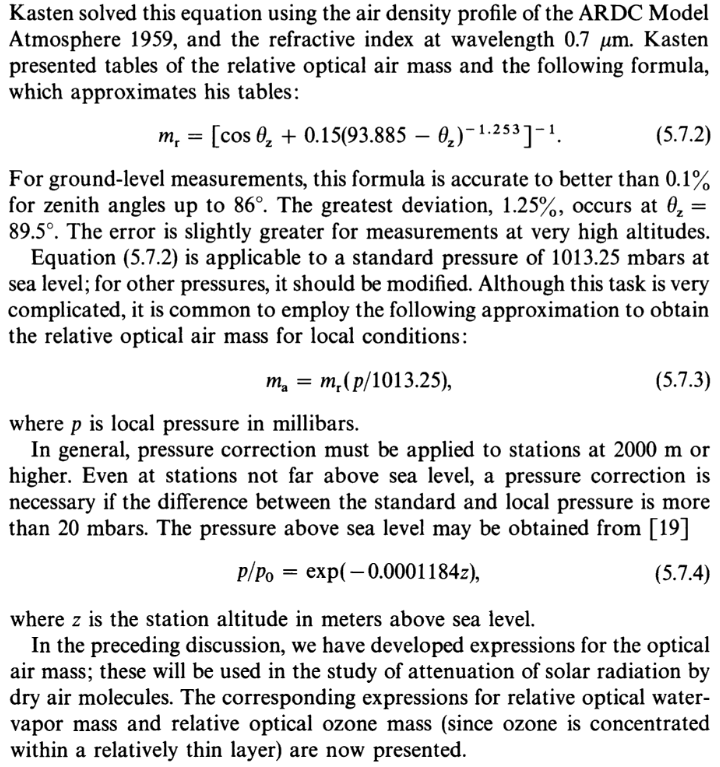

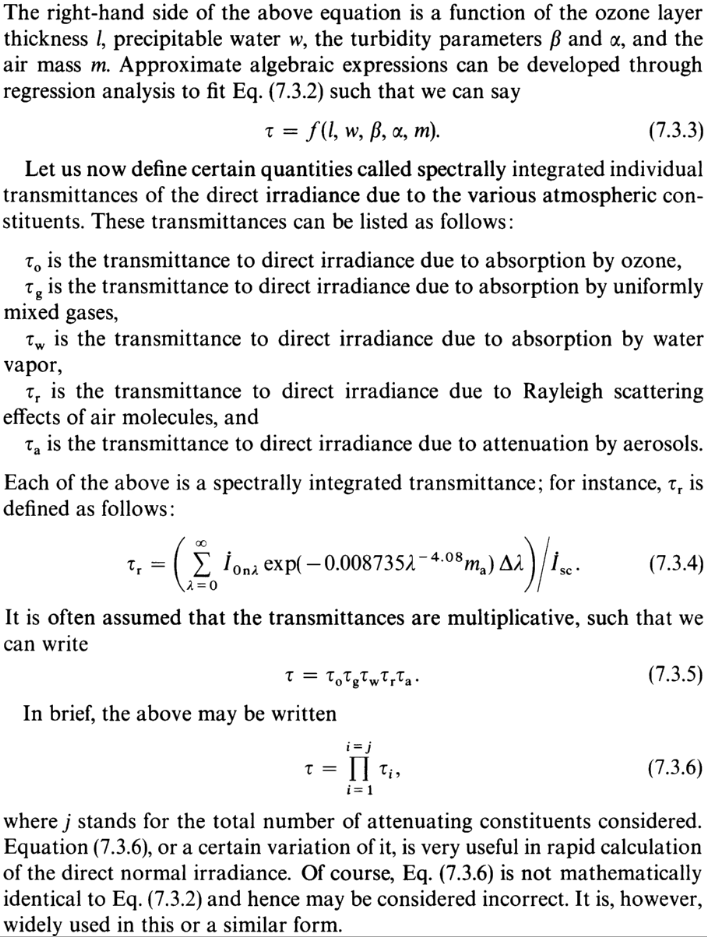

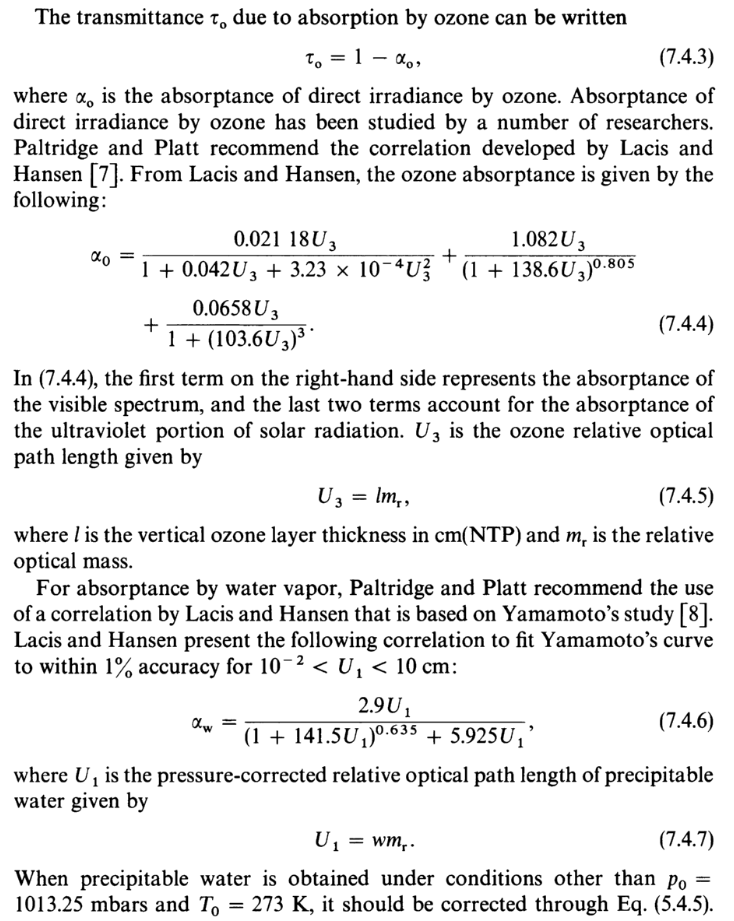

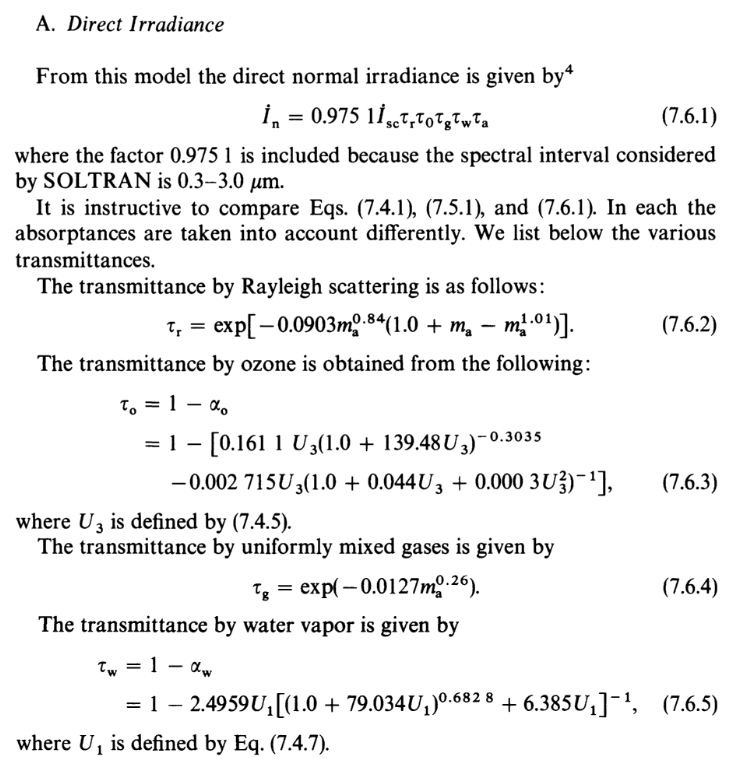

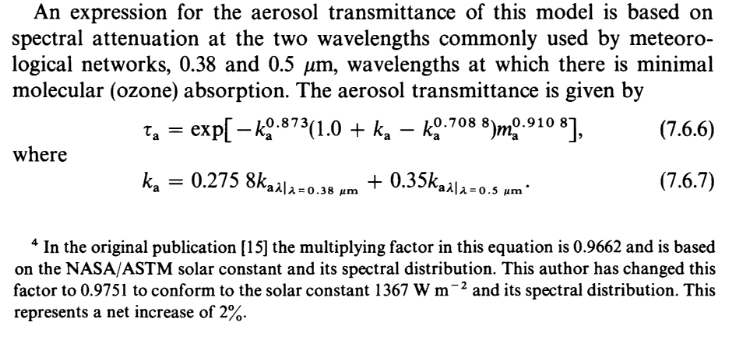

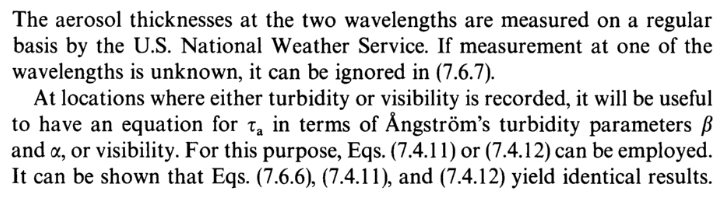

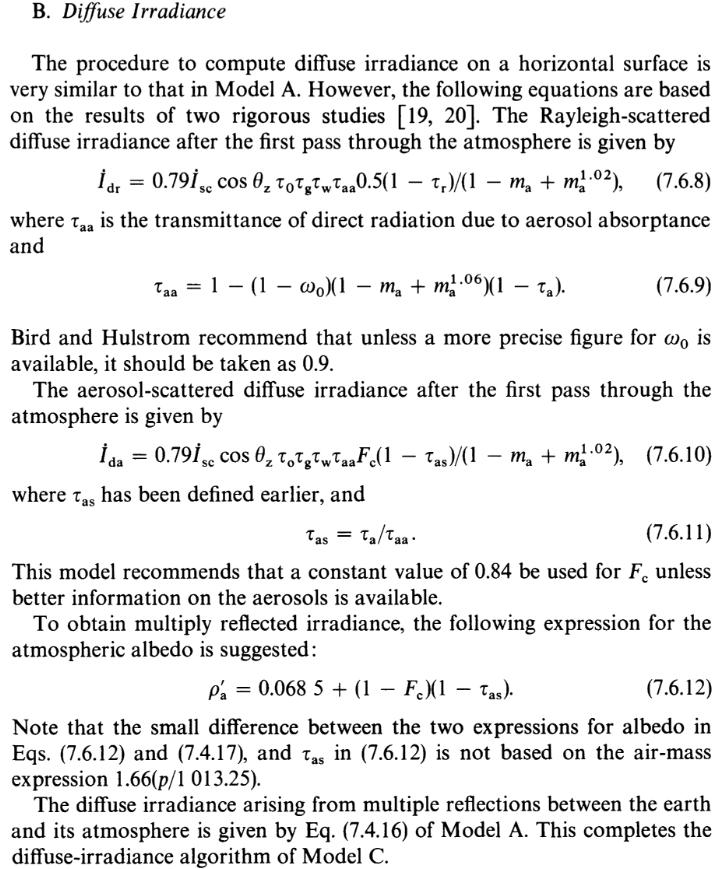

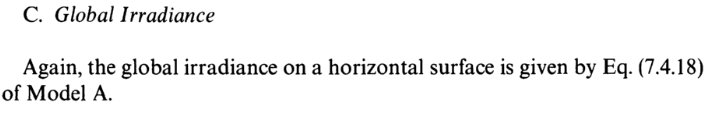

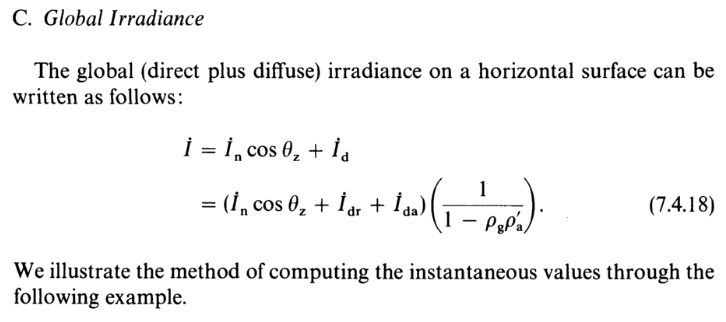

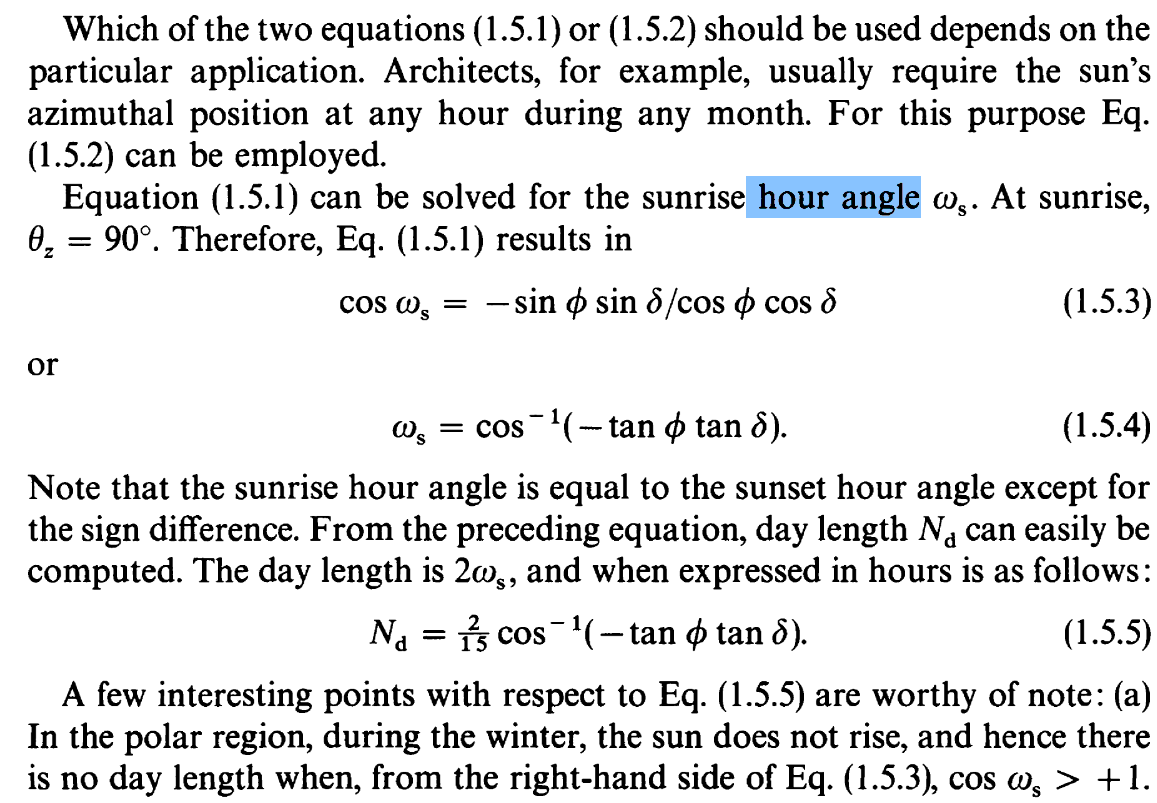

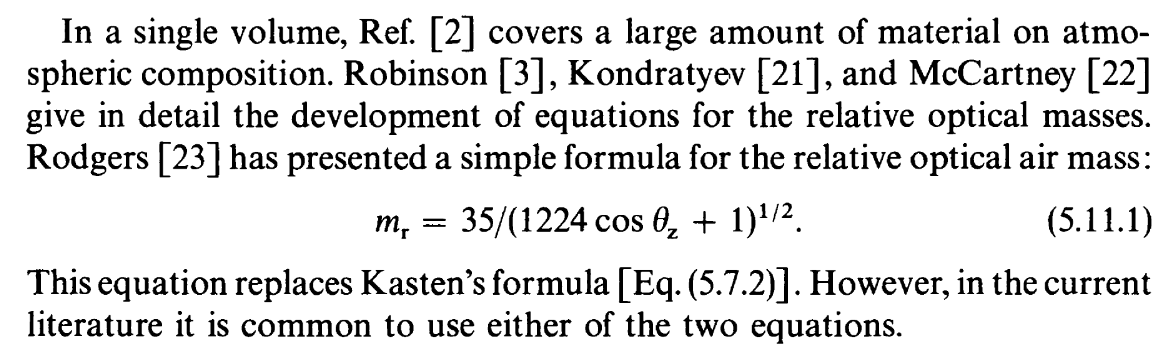

### 2.2.1. Código

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [2]:
_tmp=pd.DataFrame(['13/10/2019'],columns=['fecha'])
_tmp['fecha']=pd.to_datetime(_tmp['fecha'])
_tmp['fecha'][0]

C:\Users\PABLO\AppData\Local\Temp\ipykernel_32968\737354522.py:2: UserWarning: Parsing '13/10/2019' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  _tmp['fecha']=pd.to_datetime(_tmp['fecha'])


Timestamp('2019-10-13 00:00:00')

#### 2.2.1.1. Función día juliano

In [3]:
def get_NumOfDayJulian(date):
        return date.timetuple().tm_yday

get_NumOfDayJulian(date= _tmp['fecha'][0])

286

In [4]:
Dia_J = 286# Día Juliano
Cte_Solar = 1367 # Constante Solar W/m^2
CteSolarJ = Cte_Solar*(1+0.033*math.cos(360*Dia_J/365)) # Constante solar en función del día juliano W/m^2

t_CTA = 89 * math.pow(10,-2) # Coeficiente de transmisibilidad atmosférica, transmitancias por dispersión 
fc = 0.9662 # Factor de corrección, se ajusta a las longitudes de onda de 0.3 a 3 um del espectro solar
PI = 3.14159265

lat = -12.0175705 # Latitud Facultad de Ciencias -12.0175705,-77.0508414 sexagesimales
ang_diario = 2*PI*(Dia_J - 1)/365 # Radianes
dec_Solar = (0.006918 - 0.399912*math.cos(ang_diario) + 0.070257*math.sin(ang_diario) - 0.006758*math.cos(2*ang_diario) + 0.000907*math.sin(2*ang_diario) - 0.002697*math.cos(3*ang_diario) + 0.00148*math.sin(3*ang_diario)) # Declinación Solar en radianes
ang_horario_cte_mitadDIA = np.arccos(-math.tan(lat*PI/180)* math.tan(dec_Solar))*180/PI # grados sexagesimales, cuando TZ = 90°
hora_dia= 12# Horas

#15 grados sexagesimales var_angulo_horario <> 1 hora
#Fin_dia = 12 + ang_horario_mitadDIA/15 #Horas
Inicio_dia = 12 - ang_horario_cte_mitadDIA / 15 #Horas 5:45

ang_horario = (12 - hora_dia) * ang_horario_cte_mitadDIA * PI/ [(12 - Inicio_dia)*180]

CosenoTZ = math.sin(lat)*math.sin(dec_Solar) + math.cos(lat)*math.cos(dec_Solar)*math.cos(ang_horario)
I_DH = fc*CteSolarJ*t_CTA*CosenoTZ #Radiación solar directa en superficie horizontal

k_d = 1 * math.pow(10,-1)
TZ = np.arccos(CosenoTZ)# ThetaZenith en radianes
I_dH = CteSolarJ*k_d*math.cos(TZ) #Radiación solar difusa en la superficie horizontal

I_TOTAL = I_DH + I_dH #comparar con Solar_Rad de la Data, no estamos considerando al albedo

print('Radiación solar directa' , ':' , round(I_DH))
print('Radiación solar difusa' , ':' , round(I_dH))
print('Radiación solar Global' , ':' , round(I_TOTAL))

Radiación solar directa : 938
Radiación solar difusa : 109
Radiación solar Global : 1048


In [5]:
def RadiationSolar(Date,t_CTA,latitud,hora_dia,k_d,fc=0.9662):
    def get_NumOfDayJulian(date):
        return date.timetuple().tm_yday
    
    Dia_J = get_NumOfDayJulian(Date) # Día Juliano
    Cte_Solar = 1367 # Constante Solar W/m^2
    CteSolarJ = Cte_Solar*(1+0.033*math.cos(360*Dia_J/365)) # Constante solar en función del día juliano W/m^2

    t_CTA = t_CTA * math.pow(10,-2) # Coeficiente de transmisibilidad atmosférica, transmitancias por dispersión 
    #fc = 0.9662 # Factor de corrección, se ajusta a las longitudes de onda de 0.3 a 3 um del espectro solar
    PI = 3.14159265

    lat = latitud # Latitud Facultad de Ciencias -12.0175705,-77.0508414 sexagesimales
    ang_diario = 2*PI*(Dia_J - 1)/365 # Radianes
    dec_Solar = (0.006918 - 0.399912*math.cos(ang_diario) + 0.070257*math.sin(ang_diario) - 0.006758*math.cos(2*ang_diario) + 0.000907*math.sin(2*ang_diario) - 0.002697*math.cos(3*ang_diario) + 0.00148*math.sin(3*ang_diario)) # Declinación Solar en radianes
    ang_horario_cte_mitadDIA = np.arccos(-math.tan(lat*PI/180)* math.tan(dec_Solar))*180/PI # grados sexagesimales, cuando TZ = 90°
    #hora_dia= 12 # Horas

    #15 grados sexagesimales var_angulo_horario <> 1 hora
    #Fin_dia = 12 + ang_horario_mitadDIA/15 #Horas
    Inicio_dia = 12 - ang_horario_cte_mitadDIA / 15 #Horas 5:45

    ang_horario = (12 - hora_dia) * ang_horario_cte_mitadDIA * PI/ [(12 - Inicio_dia)*180]

    CosenoTZ = math.sin(lat)*math.sin(dec_Solar) + math.cos(lat)*math.cos(dec_Solar)*math.cos(ang_horario)
    I_DH = fc*CteSolarJ*t_CTA*CosenoTZ #Radiación solar directa en superficie horizontal

    k_d = k_d * math.pow(10,-1)
    TZ = np.arccos(CosenoTZ)# ThetaZenith en radianes
    I_dH = CteSolarJ*k_d*math.cos(TZ) #Radiación solar difusa en la superficie horizontal

    I_TOTAL = I_DH + I_dH #comparar con Solar_Rad de la Data, no estamos considerando al albedo
    
    #print('Radiación solar directa' , ':' , round(I_DH))
    #print('Radiación solar difusa' , ':' , round(I_dH))
    #print('Radiación solar Global' , ':' , round(I_TOTAL))
    return round(I_DH),round(I_dH),round(I_TOTAL)

#### 2.2.1.2. Función de inicio y fin de dia

In [6]:
Dia_J=199
PI=3.14159
lat = -12.0175705 # Latitud Facultad de Ciencias -12.0175705,-77.0508414 sexagesimales
ang_diario = 2*PI*(Dia_J - 1)/365 # Radianes
dec_Solar = (0.006918 - 0.399912*math.cos(ang_diario) + 0.070257*math.sin(ang_diario) - 0.006758*math.cos(2*ang_diario) + 0.000907*math.sin(2*ang_diario) - 0.002697*math.cos(3*ang_diario) + 0.00148*math.sin(3*ang_diario)) # Declinación Solar en radianes
ang_horario_cte_mitadDIA = np.arccos(-math.tan(lat*PI/180)* math.tan(dec_Solar))*180/PI # grados sexagesimales
Inicio_dia = 12 - ang_horario_cte_mitadDIA/15
Fin_dia = 12 + ang_horario_cte_mitadDIA/15

def ang2hour(x):
    h=math.trunc(x)
    m=(x-h)*60
    print(h,":",round(m))

ang2hour(Inicio_dia)
ang2hour(Fin_dia)

6 : 19
17 : 41


# 3. Tratamiento de datos

In [7]:
path='D:/Anaconda/WeatherData/Data/'
df1 = pd.read_csv(path + 'UNI_EMDI-LabSolar_fd07122022.txt', sep="\t")
df1.head()

C:\Users\PABLO\AppData\Local\Temp\ipykernel_32968\2870946907.py:2: DtypeWarning: Columns (2,3,4,5,6,7,9,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(path + 'UNI_EMDI-LabSolar_fd07122022.txt', sep="\t")


,Unnamed: 0,Unnamed: 1,Temp,Hi,Low,Out,Dew,Wind,Wind.1,Wind.2,...,In,In .1,In .2,In .3,In Air,Unnamed: 33,Wind.4,Wind.5,ISS,Arc.
0,Date,Time,Out,Temp,Temp,Hum,Pt.,Speed,Dir,Run,...,Hum,Dew,Heat,EMC,Density,ET,Samp,Tx,Recept,Int.
1,13/10/19,11:00,18.3,18.4,18.3,78,14.4,1.3,WNW,0.80,...,50,13.6,24.7,9.22,1.1716,0.004,234,1,100.0,10
2,13/10/19,11:10,18.1,18.3,18.1,79,14.4,1.8,WNW,1.07,...,50,13.6,24.7,9.22,1.1717,0.000,235,1,100.0,10
3,13/10/19,11:20,18.2,18.2,18.1,79,14.5,1.3,WNW,0.80,...,50,13.6,24.7,9.22,1.1714,0.000,234,1,100.0,10
4,13/10/19,11:30,18.2,18.3,18.2,79,14.5,1.3,WNW,0.80,...,50,13.7,24.8,9.22,1.1712,0.000,234,1,100.0,10


In [8]:
print(df1.dtypes, end='\n\n')
print(df1.describe())

Unnamed: 0     object
Unnamed: 1     object
Temp           object
Hi             object
Low            object
Out            object
Dew            object
Wind           object
Wind.1         object
Wind.2         object
Hi.1           object
Hi.2           object
Wind.3         object
Heat           object
THW            object
THSW           object
Unnamed: 16    object
Unnamed: 17    object
Rain           object
Solar          object
Solar.1        object
Hi Solar       object
UV             object
UV .1          object
Hi             object
Heat.1         object
Cool           object
In             object
In             object
In .1          object
In .2          object
In .3          object
In Air         object
Unnamed: 33    object
Wind.4         object
Wind.5         object
ISS            object
Arc.           object
dtype: object

       Unnamed: 0 Unnamed: 1      Temp        Hi       Low     Out       Dew  \
count      165493     165493  165493.0  165493.0  165493.0  165493  1

In [9]:
df1.iloc[:, [0,1,2,19]]

,Unnamed: 0,Unnamed: 1,Temp,Solar
0,Date,Time,Out,Rad.
1,13/10/19,11:00,18.3,112
2,13/10/19,11:10,18.1,93
3,13/10/19,11:20,18.2,95
4,13/10/19,11:30,18.2,108
...,...,...,...,...
165488,07/12/22,20:10,18.9,0
165489,07/12/22,20:20,18.9,0
165490,07/12/22,20:30,18.8,0
165491,07/12/22,20:40,18.8,0


In [10]:
sel_cols = ['Unnamed: 0','Unnamed: 1','Temp','Solar']
data = df1[sel_cols].copy()
data = data[1:].reset_index(drop=True)
sel_cols_newname = ['Date','Time','TempOut','SolarRad']
data.columns = sel_cols_newname
data['DateTime'] = pd.to_datetime(data['Date']+' '+data['Time'],format='%d/%m/%y %H:%M')
print(data, end = '\n\n')
print(data.dtypes)

            Date   Time TempOut SolarRad            DateTime
0       13/10/19  11:00    18.3      112 2019-10-13 11:00:00
1       13/10/19  11:10    18.1       93 2019-10-13 11:10:00
2       13/10/19  11:20    18.2       95 2019-10-13 11:20:00
3       13/10/19  11:30    18.2      108 2019-10-13 11:30:00
4       13/10/19  11:40    18.1      136 2019-10-13 11:40:00
...          ...    ...     ...      ...                 ...
165487  07/12/22  20:10    18.9        0 2022-12-07 20:10:00
165488  07/12/22  20:20    18.9        0 2022-12-07 20:20:00
165489  07/12/22  20:30    18.8        0 2022-12-07 20:30:00
165490  07/12/22  20:40    18.8        0 2022-12-07 20:40:00
165491  07/12/22  20:50    18.7        0 2022-12-07 20:50:00

[165492 rows x 5 columns]

Date                object
Time                object
TempOut             object
SolarRad            object
DateTime    datetime64[ns]
dtype: object


In [11]:
NumHuecoSolarRad = 0
NumHuecoTempOut = 0
print("HuecoSolarRad")
for f in data.SolarRad:
    try:
        float(f)
    except:
        print(f)
        NumHuecoSolarRad = NumHuecoSolarRad + 1
print("HuecoTempOut")
for e in data.TempOut:
    try:
        float(e)
    except:
        print(e)
        NumHuecoTempOut = NumHuecoTempOut + 1

print("Numero de huecos en SolarRad: ", NumHuecoSolarRad)
print("Numero de huecos en TempOut: ", NumHuecoTempOut)

HuecoSolarRad
---
---
---
---
HuecoTempOut
---
---
---
---
Numero de huecos en SolarRad:  4
Numero de huecos en TempOut:  4


In [12]:
data[data['TempOut']=='---']

,Date,Time,TempOut,SolarRad,DateTime
6507,27/11/19,16:26,---,---,2019-11-27 16:26:00
72557,28/02/21,14:00,---,---,2021-02-28 14:00:00
76002,24/03/21,12:50,---,---,2021-03-24 12:50:00
107947,01/11/21,12:32,---,---,2021-11-01 12:32:00


In [13]:
data[data['SolarRad']=='---']

,Date,Time,TempOut,SolarRad,DateTime
6507,27/11/19,16:26,---,---,2019-11-27 16:26:00
72557,28/02/21,14:00,---,---,2021-02-28 14:00:00
76002,24/03/21,12:50,---,---,2021-03-24 12:50:00
107947,01/11/21,12:32,---,---,2021-11-01 12:32:00


In [14]:
data[data.DateTime.dt.minute % 10 != 0].sort_values(by='DateTime',ascending=True)

,Date,Time,TempOut,SolarRad,DateTime
6507,27/11/19,16:26,---,---,2019-11-27 16:26:00
11598,02/01/20,8:36,21.2,49,2020-01-02 08:36:00
11611,02/01/20,10:42,23.8,184,2020-01-02 10:42:00
11627,02/01/20,13:22,27.2,469,2020-01-02 13:22:00
11658,02/01/20,18:43,24.8,5,2020-01-02 18:43:00
...,...,...,...,...,...
107947,01/11/21,12:32,---,---,2021-11-01 12:32:00
111287,24/11/21,17:11,20.1,36,2021-11-24 17:11:00
121053,31/01/22,12:51,27.4,402,2022-01-31 12:51:00
122060,07/02/22,12:43,27.0,1049,2022-02-07 12:43:00


Función día juliano (Argumento en formato fecha)

In [15]:
def get_NumOfDayJulian(date):
    return date.timetuple().tm_yday

In [26]:
data['DateTime'][70:90].apply(lambda x: RadiationSolar(Date=x,t_CTA=89,latitud=-12.0175705,hora_dia=12,k_d=1,fc=0.9662))

70    (938, 109, 1048)
71    (938, 109, 1048)
72    (938, 109, 1048)
73    (938, 109, 1048)
74    (938, 109, 1048)
75    (938, 109, 1048)
76    (938, 109, 1048)
77    (938, 109, 1048)
78    (938, 109, 1047)
79    (938, 109, 1047)
80    (938, 109, 1047)
81    (938, 109, 1047)
82    (938, 109, 1047)
83    (938, 109, 1047)
84    (938, 109, 1047)
85    (938, 109, 1047)
86    (938, 109, 1047)
87    (938, 109, 1047)
88    (938, 109, 1047)
89    (938, 109, 1047)
Name: DateTime, dtype: object

In [17]:
data['I_DH']=data['DateTime'].apply(lambda x: RadiationSolar(Date=x,t_CTA=89,latitud=-12.0175705,hora_dia = (x.hour + (x.minute/60)),k_d=1,fc=0.9662)[0])
data['I_dH']=data['DateTime'].apply(lambda x: RadiationSolar(Date=x,t_CTA=89,latitud=-12.0175705,hora_dia = (x.hour + (x.minute/60)),k_d=1,fc=0.9662)[1])
data['I_TOTAL']=data['DateTime'].apply(lambda x: RadiationSolar(Date=x,t_CTA=89,latitud=-12.0175705,hora_dia = (x.hour + (x.minute/60)),k_d=1,fc=0.9662)[2])

data.loc[data['I_TOTAL']<=0,'I_TOTAL'] = 0

<AxesSubplot:>

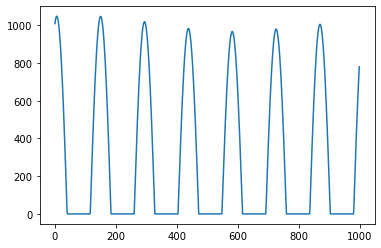

In [18]:
data['I_TOTAL'][:1000].plot()

In [19]:
data

,Date,Time,TempOut,SolarRad,DateTime,I_DH,I_dH,I_TOTAL
0,13/10/19,11:00,18.3,112,2019-10-13 11:00:00,904,105,1009
1,13/10/19,11:10,18.1,93,2019-10-13 11:10:00,914,106,1021
2,13/10/19,11:20,18.2,95,2019-10-13 11:20:00,923,107,1030
3,13/10/19,11:30,18.2,108,2019-10-13 11:30:00,930,108,1038
4,13/10/19,11:40,18.1,136,2019-10-13 11:40:00,935,109,1043
...,...,...,...,...,...,...,...,...
165487,07/12/22,20:10,18.9,0,2022-12-07 20:10:00,-709,-82,0
165488,07/12/22,20:20,18.9,0,2022-12-07 20:20:00,-741,-86,0
165489,07/12/22,20:30,18.8,0,2022-12-07 20:30:00,-773,-90,0
165490,07/12/22,20:40,18.8,0,2022-12-07 20:40:00,-803,-93,0


In [20]:
col01=df1['Unnamed: 0']
col02=df1['Unnamed: 1']
col03=df1['Temp']
col04=df1['Solar']
horizontal_stack = pd.concat([col01, col02, col03, col04], axis=1) # apilamiento horizontal (axis=1)
horizontal_stack

,Unnamed: 0,Unnamed: 1,Temp,Solar
0,Date,Time,Out,Rad.
1,13/10/19,11:00,18.3,112
2,13/10/19,11:10,18.1,93
3,13/10/19,11:20,18.2,95
4,13/10/19,11:30,18.2,108
...,...,...,...,...
165488,07/12/22,20:10,18.9,0
165489,07/12/22,20:20,18.9,0
165490,07/12/22,20:30,18.8,0
165491,07/12/22,20:40,18.8,0


In [21]:
path='D:/Anaconda/WeatherData/Data/'
horizontal_stack.to_csv(path + 'SelecData.txt', index=False) # Crea archivo con la data seccionada
df2 = pd.read_csv(path + 'SelecData.txt', header=None, names=['Date', 'Time', 'Temp_out', 'Solar_Rad']) # Agrega encabezado
df2.head()

C:\Users\PABLO\AppData\Local\Temp\ipykernel_32968\3907702207.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(path + 'SelecData.txt', header=None, names=['Date', 'Time', 'Temp_out', 'Solar_Rad']) # Agrega encabezado


,Date,Time,Temp_out,Solar_Rad
0,Unnamed: 0,Unnamed: 1,Temp,Solar
1,Date,Time,Out,Rad.
2,13/10/19,11:00,18.3,112
3,13/10/19,11:10,18.1,93
4,13/10/19,11:20,18.2,95


In [22]:
path='D:/Anaconda/WeatherData/Data/'
df2.drop([0,1],axis=0).to_csv(path + 'SelecData.txt',index=False) # Eliminar de manera vertical (axis=0)
pd.read_csv(path + 'SelecData.txt')

C:\Users\PABLO\AppData\Local\Temp\ipykernel_32968\2991796292.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(path + 'SelecData.txt')


,Date,Time,Temp_out,Solar_Rad
0,13/10/19,11:00,18.3,112
1,13/10/19,11:10,18.1,93
2,13/10/19,11:20,18.2,95
3,13/10/19,11:30,18.2,108
4,13/10/19,11:40,18.1,136
...,...,...,...,...
165487,07/12/22,20:10,18.9,0
165488,07/12/22,20:20,18.9,0
165489,07/12/22,20:30,18.8,0
165490,07/12/22,20:40,18.8,0


In [23]:
path='D:/Anaconda/WeatherData/Data/'
df3 = pd.read_csv(path + 'SelecData.txt', sep=",")
df3.head()

C:\Users\PABLO\AppData\Local\Temp\ipykernel_32968\954093571.py:2: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv(path + 'SelecData.txt', sep=",")


,Date,Time,Temp_out,Solar_Rad
0,13/10/19,11:00,18.3,112
1,13/10/19,11:10,18.1,93
2,13/10/19,11:20,18.2,95
3,13/10/19,11:30,18.2,108
4,13/10/19,11:40,18.1,136


In [24]:
df3.shape

(165492, 4)

In [25]:
df3.describe()

,Date,Time,Temp_out,Solar_Rad
count,165492,165492,165492,165492
unique,1152,288,328,2095
top,05/02/20,19:10,17.3,0
freq,191,1151,1780,66354


Se ha separado las columnas. Falta ver los huecos de manera temporal.